# ECDFs of s per site — SNP, indel, SV plotted separately

Cumulative distribution of the plot-replicate selection coefficient s, one curve per class, per site.
SNP and indel are **frequency-matched** to the SV p₀ distribution (resampled) so the three curves are
comparable — otherwise SVs' rarity alone would shift them. No MAF filter.

- **x = s** (left = purged, right = favoured); **y = cumulative fraction** P(s ≤ x).
- A curve that is **higher / to the left** reaches a given cumulative probability at more-negative s
  ⇒ that class is more purged. If SNP/indel/SV overlie ⇒ identical selection distributions.
- Grey vertical line = s = 0 (neutral). Panels ordered + colour-coded cold→hot (bio1).

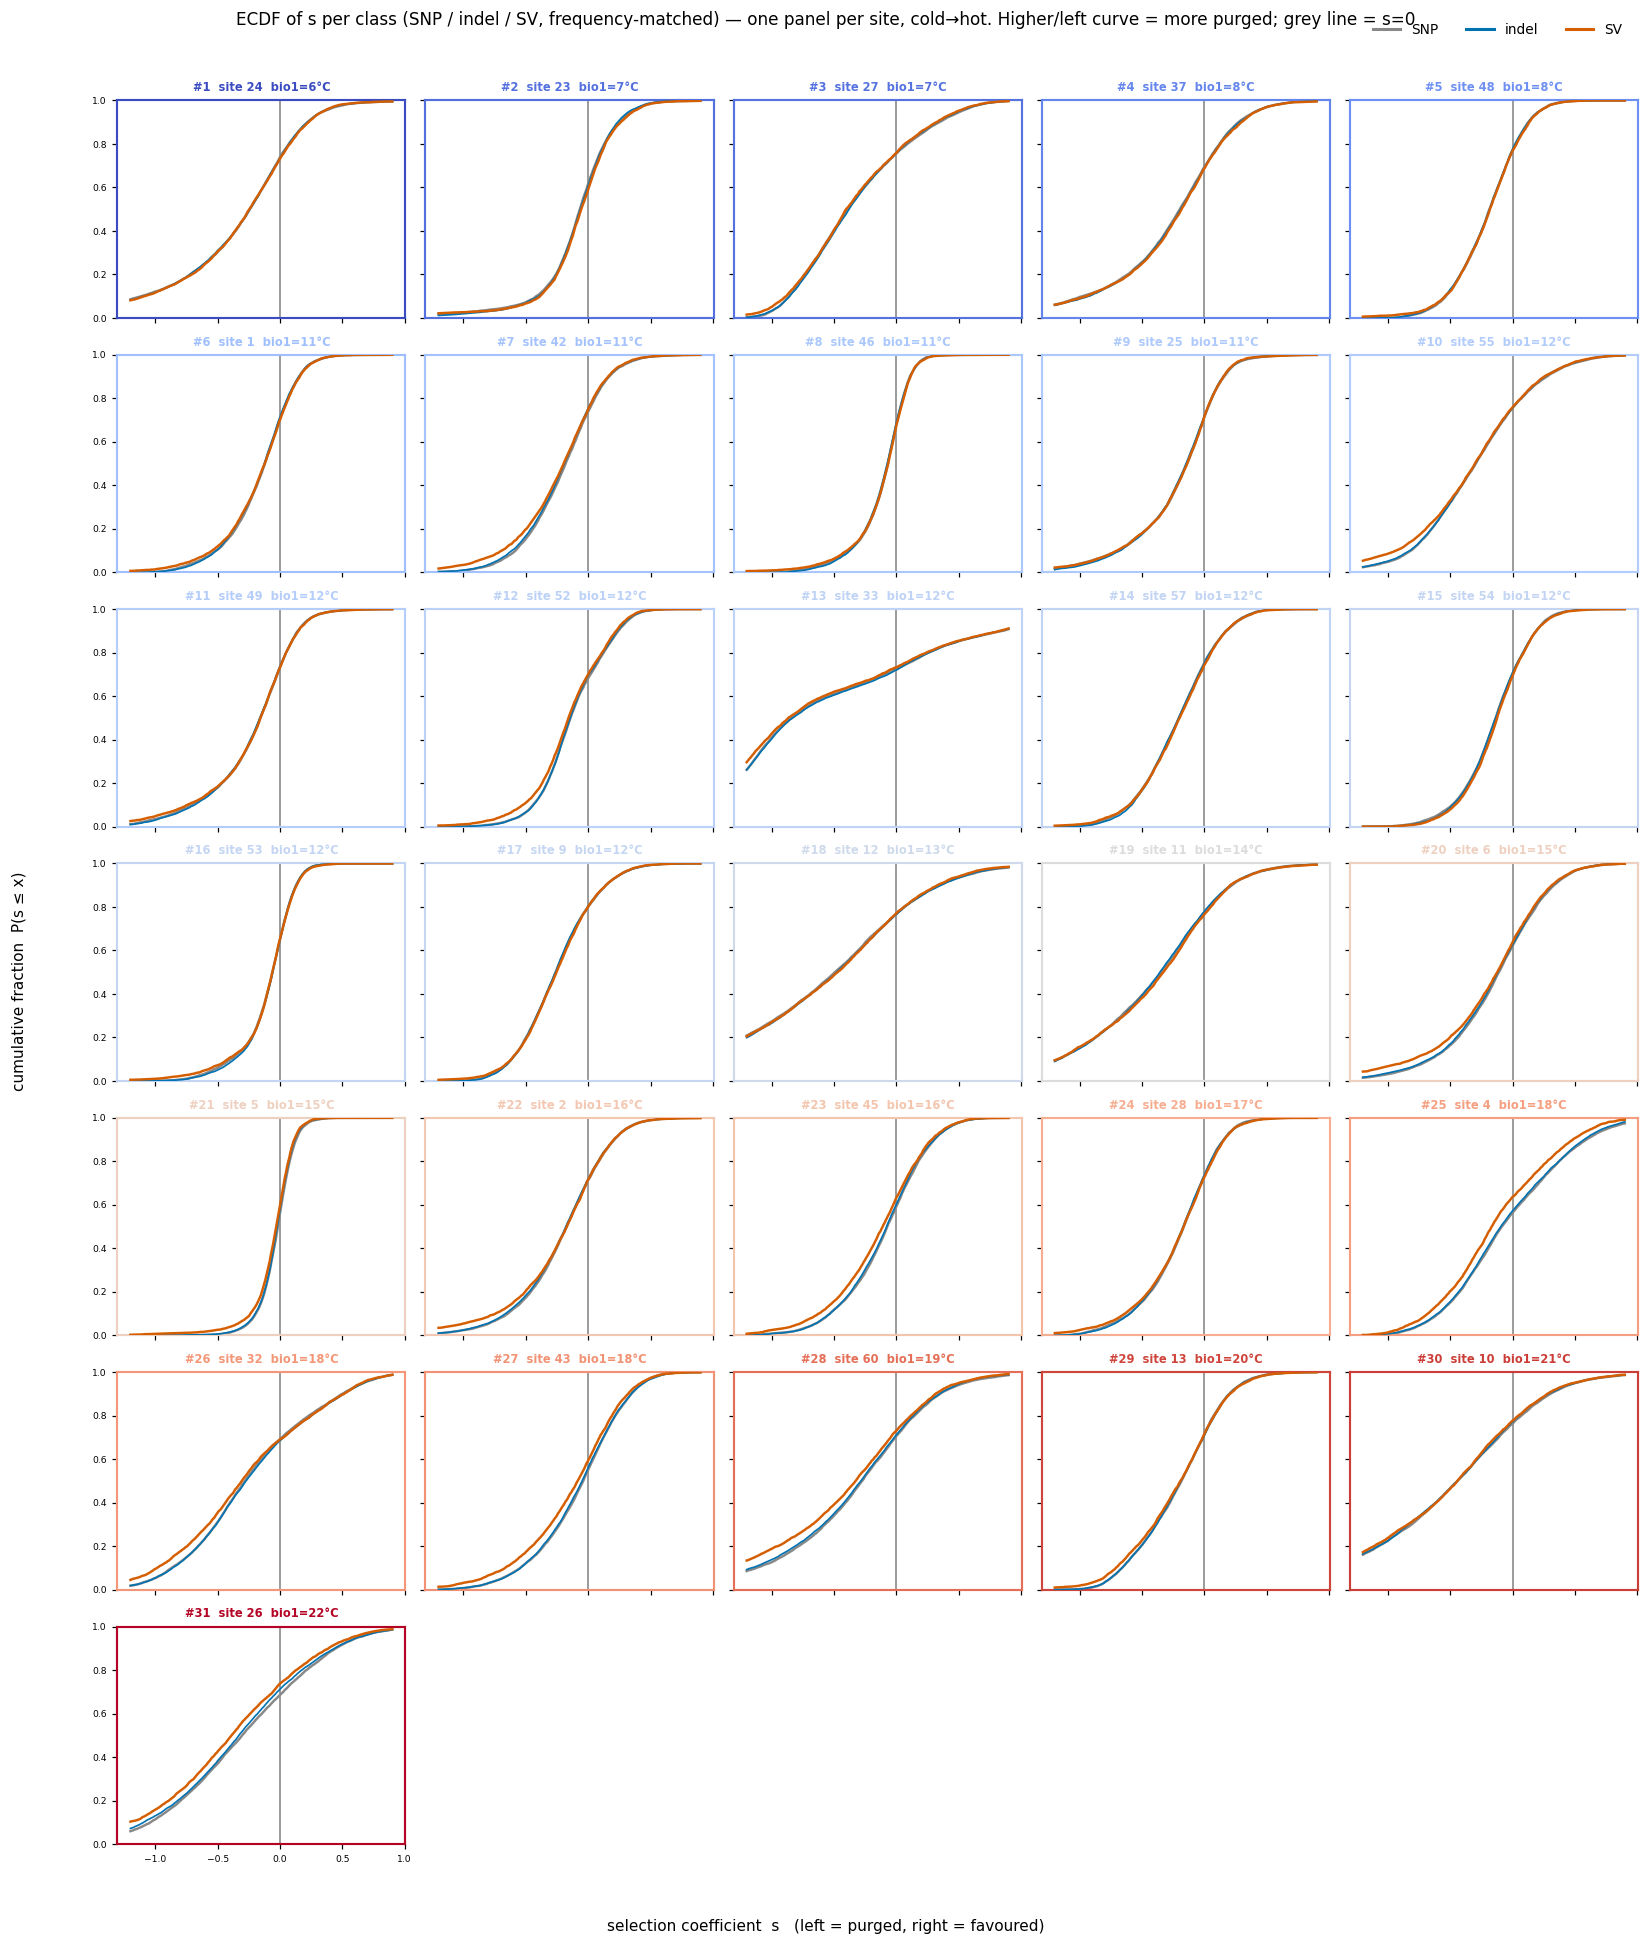

saved s_ecdf_by_site.png


In [1]:

import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams.update({'figure.dpi':110,'font.size':8,'axes.linewidth':0.6})
G = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/sv_adaptive"
npz = np.load(f"{G}/s_dist_by_stratum.npz")
meta = pd.read_csv(f"{G}/s_dist_by_stratum_sitemeta.csv").sort_values("bio1").reset_index(drop=True)
COL = {"SNP":"#888888","indel":"#0072B2","SV":"#D55E00"}
NBIN, NDRAW = 25, 20000; rng = np.random.default_rng(0)
GRID = np.linspace(-1.2, 0.9, 240)

def match_to(tp0, ss, sp0):
    e=np.quantile(np.concatenate([tp0,sp0]),np.linspace(0,1,NBIN+1)); e[-1]+=1e-9
    tb=np.digitize(tp0,e[1:-1]); sb=np.digitize(sp0,e[1:-1]); out=[]
    for b in range(NBIN):
        k=int(round((tb==b).mean()*NDRAW)); pool=ss[sb==b]
        if k>0 and pool.size: out.append(rng.choice(pool,k,replace=True))
    return np.concatenate(out)
def ecdf(s): ss=np.sort(s); return np.searchsorted(ss, GRID, side="right")/ss.size

sites = meta.site.tolist()
ncol, nrow = 5, int(np.ceil(len(sites)/5))
norm = mpl.colors.Normalize(vmin=meta.bio1.min(), vmax=meta.bio1.max()); cmap = mpl.cm.coolwarm
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.5*nrow), sharex=True, sharey=True)
axes = axes.ravel()
for ax in axes[len(sites):]: ax.axis("off")
for i, s in enumerate(sites):
    ax = axes[i]; p_sv = npz[f"{s}_p0_SV"]
    e_sv = ecdf(npz[f"{s}_s_SV"])
    e_sn = ecdf(match_to(p_sv, npz[f"{s}_s_SNP"],   npz[f"{s}_p0_SNP"]))
    e_in = ecdf(match_to(p_sv, npz[f"{s}_s_indel"], npz[f"{s}_p0_indel"]))
    ax.axvline(0, color="0.5", lw=1.0, zorder=1)
    ax.plot(GRID, e_sn, color=COL["SNP"],   lw=1.6, zorder=2)
    ax.plot(GRID, e_in, color=COL["indel"], lw=1.1, zorder=3)
    ax.plot(GRID, e_sv, color=COL["SV"],    lw=1.6, zorder=4)
    b1 = meta[meta.site==s].bio1.iloc[0]; c = cmap(norm(b1))
    ax.set_title(f"#{i+1}  site {s}  bio1={b1:.0f}°C", fontsize=7.5, color=c, fontweight="bold")
    for sp in ax.spines.values(): sp.set_color(c); sp.set_linewidth(1.4)
    ax.set_ylim(0,1); ax.tick_params(labelsize=6)
fig.supxlabel("selection coefficient  s   (left = purged, right = favoured)", y=0.005, fontsize=10)
fig.supylabel("cumulative fraction  P(s ≤ x)", x=0.006, fontsize=10)
fig.legend(handles=[Line2D([0],[0],color=COL[c],lw=2,label=c) for c in ["SNP","indel","SV"]],
           loc="upper right", ncol=3, fontsize=9, frameon=False, bbox_to_anchor=(0.99,1.004))
fig.suptitle("ECDF of s per class (SNP / indel / SV, frequency-matched) — one panel per site, "
             "cold→hot. Higher/left curve = more purged; grey line = s=0", fontsize=11, y=1.004)
fig.tight_layout(rect=[0.03,0.02,1,0.99])
fig.savefig(f"{G}/s_ecdf_by_site.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved s_ecdf_by_site.png")


### Reading
- Where the **orange (SV) curve rises above the grey (SNP)/blue (indel) curves on the left of s=0**,
  SVs have more probability mass in the purged region → more purifying selection. That gap grows at
  the hot (red-bordered) panels and is ~absent at cold (blue-bordered) ones.
- SNP and indel curves essentially coincide everywhere. The SV↔SNP gap is small (a few % of
  cumulative probability) — visible here but far subtler than in the ECDF-*difference* view, which is
  why that difference plot is the more sensitive companion.